# Gradient Boosting Baseline Model

**Module:** IT3051 - Fundamentals of Data Mining  
**Project:** Next-Year PM2.5 Air-Quality Risk Classification  
**Model:** Gradient Boosting Classifier  
**Purpose:** Baseline model development and validation

This notebook:

- Loads the chronological train/validation/test datasets created by `07_make_dataset.ipynb`
- Reuses the preprocessing logic from `10_preprocessing_pipeline.ipynb`
- Fits preprocessing **only on training data** to prevent leakage
- Trains a baseline Gradient Boosting model
- Evaluates the model on the validation set
- Reports Accuracy, Macro F1, Classification Report, and Confusion Matrix
- Keeps the test set untouched for later final-model evaluation

> This is a **baseline** Gradient Boosting. Hyperparameter tuning and model optimization are intentionally not performed here.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Make this work when the notebook is run from the project's notebooks folder
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing.preprocessing_pipeline import (
    TARGET_COLUMN,
    prepare_base_dataframe,
    prepare_features_and_target,
    build_preprocessor,
)

print("Imports loaded successfully.")
print("Project root:", project_root)


Imports loaded successfully.
Project root: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project


## 1. Load Chronological Split Datasets

`07_make_dataset.ipynb` creates chronological splits:

- Training: years up to 2012
- Validation: 2013-2014
- Test: 2015 onward

We load the full split files because they contain both the predictors and target.


In [2]:
processed_dir = project_root / "data" / "processed"

train_path = processed_dir / "train_data.csv"
validation_path = processed_dir / "validation_data.csv"
test_path = processed_dir / "test_data.csv"

required_files = [train_path, validation_path, test_path]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}\n"
            "Run 07_make_dataset.ipynb first to create the chronological split files."
        )

identifier_types = {
    "site_id": "string",
    "state_code": "string",
    "county_code": "string",
    "site_num": "string",
}

train_df = pd.read_csv(train_path, dtype=identifier_types, low_memory=False)
validation_df = pd.read_csv(validation_path, dtype=identifier_types, low_memory=False)
test_df = pd.read_csv(test_path, dtype=identifier_types, low_memory=False)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)


Training shape: (13191, 38)
Validation shape: (1783, 38)
Test shape: (1561, 38)


## 2. Confirm the Chronological Split

This check helps confirm that future years are not mixed into the training data.


In [3]:
for name, dataset in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Test", test_df),
]:
    print(
        f"{name}: {dataset['year'].min()} - {dataset['year'].max()} "
        f"({len(dataset)} rows)"
    )


Training: 1997 - 2012 (13191 rows)
Validation: 2013 - 2014 (1783 rows)
Test: 2015 - 2016 (1561 rows)


## 3. Apply Base Cleaning to Each Split

We use the same base-cleaning function used in the preprocessing notebook.  
Each split is handled separately.


In [4]:
train_prepared = prepare_base_dataframe(train_df)
validation_prepared = prepare_base_dataframe(validation_df)
test_prepared = prepare_base_dataframe(test_df)

print("Base preprocessing completed.")
print("Training shape:", train_prepared.shape)
print("Validation shape:", validation_prepared.shape)
print("Test shape:", test_prepared.shape)


Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Base preprocessing completed.
Training shape: (13191, 38)
Validation shape: (1783, 38)
Test shape: (1561, 38)


## 4. Separate Features and Target

The target is `pm25_risk_category_next_year`.

Identifier columns are excluded by the existing project preprocessing function.


In [5]:
X_train, y_train = prepare_features_and_target(train_prepared)
X_val, y_val = prepare_features_and_target(validation_prepared)
X_test, y_test = prepare_features_and_target(test_prepared)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())


Feature matrix shape: (13191, 33)
Target shape: (13191,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1783, 33)
Target shape: (1783,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1561, 33)
Target shape: (1561,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
X_train: (13191, 33) | y_train: (13191,)
X_val: (1783, 33) | y_val: (1783,)
X_test: (1561, 33) | y_test: (1561,)

Training target distribution:
pm25_risk_category_next_year
Moderate                          6849
Unhealthy for Sensitive Groups    5049
Unhealthy                         1203
Good                                52
Very Unhealthy                      38
Name: count, dtype: int64


## 5. Build and Fit the Preprocessor

Important: the preprocessor is **fitted only on `X_train`**.

The fitted training preprocessor is then used to transform validation and test features.  
This prevents information leakage from future data.


In [6]:
preprocessor = build_preprocessor(X_train)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# Prepare test features with the same fitted transformer,
# but do not use y_test for baseline model selection.
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed.")
print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Numerical features: 29
Categorical features: 4
Preprocessing completed.
Processed training shape: (13191, 2154)
Processed validation shape: (1783, 2154)
Processed test shape: (1561, 2154)


## 6. Create the Baseline Gradient Boosting

No hyperparameter search is performed here.

`random_state=42` is used so the experiment is reproducible.


In [7]:
gb_baseline = GradientBoostingClassifier(
    random_state=42
)

gb_baseline


,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

## 7. Train the Model


In [8]:
gb_baseline.fit(X_train_processed, y_train)

print("Gradient Boosting baseline training completed.")


Gradient Boosting baseline training completed.


## 8. Predict the Validation Set

The validation set is used to evaluate this baseline model.  
The test labels remain untouched for later final-model evaluation.


In [9]:
y_val_pred = gb_baseline.predict(X_val_processed)

print("Validation predictions completed.")


Validation predictions completed.


## 9. Baseline Evaluation Metrics

Because the target classes are imbalanced, we report both:

- Accuracy
- Macro F1 Score

Macro F1 gives equal importance to each class.


In [10]:
accuracy = accuracy_score(y_val, y_val_pred)
macro_f1 = f1_score(y_val, y_val_pred, average="macro")

print("RANDOM FOREST BASELINE - VALIDATION RESULTS")
print("=" * 55)
print(f"Accuracy : {accuracy:.4f}")
print(f"Macro F1 : {macro_f1:.4f}")


RANDOM FOREST BASELINE - VALIDATION RESULTS
Accuracy : 0.7504
Macro F1 : 0.3086


## 10. Classification Report

This shows precision, recall, and F1-score for each target class.


In [11]:
print(
    classification_report(
        y_val,
        y_val_pred,
        zero_division=0,
    )
)


                                precision    recall  f1-score   support

                          Good       0.00      0.00      0.00         5
                      Moderate       0.79      0.96      0.87      1282
                     Unhealthy       0.55      0.33      0.41       127
Unhealthy for Sensitive Groups       0.53      0.17      0.26       356
                Very Unhealthy       0.00      0.00      0.00        13

                      accuracy                           0.75      1783
                     macro avg       0.37      0.29      0.31      1783
                  weighted avg       0.71      0.75      0.70      1783



## 11. Confusion Matrix

The confusion matrix shows which risk categories the model predicts correctly and which categories are confused with each other.


Confusion matrix saved to: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\gradient_boosting_baseline_confusion_matrix.png


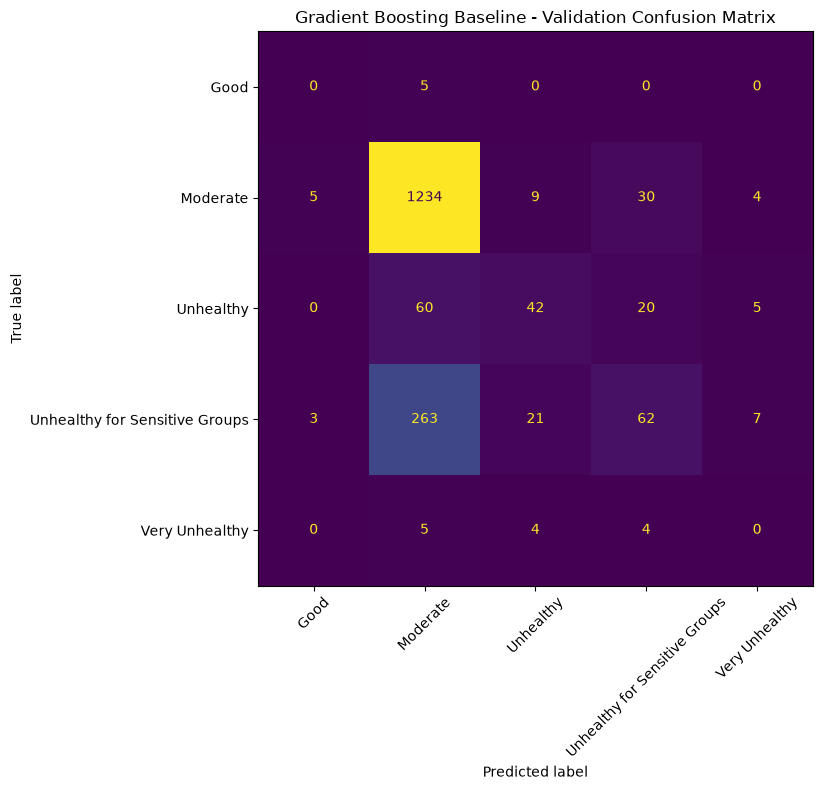

In [12]:
labels = sorted(pd.Series(y_val).dropna().unique())

cm = confusion_matrix(
    y_val,
    y_val_pred,
    labels=labels,
)

fig, ax = plt.subplots(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

display.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
    colorbar=False,
)

ax.set_title("Gradient Boosting Baseline - Validation Confusion Matrix")
plt.tight_layout()

# Save the confusion matrix image for the report/presentation
pictures_dir = project_root / "reports" / "pictures"
pictures_dir.mkdir(parents=True, exist_ok=True)

picture_path = pictures_dir / "gradient_boosting_baseline_confusion_matrix.png"
plt.savefig(picture_path, dpi=300, bbox_inches="tight")

print("Confusion matrix saved to:", picture_path)

plt.show()


## 12. Save Overall Baseline Metrics

Save the main validation metrics so they can later be compared with Gradient Boosting and the other group models.


In [13]:
results_dir = project_root / "reports" / "model_results"
pictures_dir = project_root / "reports" / "pictures"

results_dir.mkdir(parents=True, exist_ok=True)
pictures_dir.mkdir(parents=True, exist_ok=True)

baseline_results = pd.DataFrame(
    [{
        "model": "Gradient Boosting Baseline",
        "validation_accuracy": accuracy,
        "validation_macro_f1": macro_f1,
        "hyperparameter_tuning": False,
        "model_optimization": False,
    }]
)

baseline_results_path = results_dir / "gradient_boosting_baseline_results.csv"
baseline_results.to_csv(baseline_results_path, index=False)

print("Saved:", baseline_results_path)
baseline_results


Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\gradient_boosting_baseline_results.csv


,model,validation_accuracy,validation_macro_f1,hyperparameter_tuning,model_optimization
0,Gradient Boosting Baseline,0.750421,0.308555,False,False


## 13. Save the Classification Report

This preserves class-wise precision, recall, F1-score, and support as a CSV file for the report and later model comparison.


In [14]:
classification_report_dict = classification_report(
    y_val,
    y_val_pred,
    output_dict=True,
    zero_division=0,
)

classification_report_df = pd.DataFrame(classification_report_dict).transpose()

classification_report_path = (
    results_dir / "gradient_boosting_classification_report.csv"
)
classification_report_df.to_csv(classification_report_path)

print("Saved:", classification_report_path)
classification_report_df


Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\gradient_boosting_classification_report.csv


,precision,recall,f1-score,support
Good,0.000000,0.000000,0.000000,5.000000
Moderate,0.787492,0.962559,0.866269,1282.000000
Unhealthy,0.552632,0.330709,0.413793,127.000000
Unhealthy for Sensitive Groups,0.534483,0.174157,0.262712,356.000000
Very Unhealthy,0.000000,0.000000,0.000000,13.000000
accuracy,0.750421,0.750421,0.750421,0.750421
macro avg,0.374921,0.293485,0.308555,1783.000000
weighted avg,0.712297,0.750421,0.704786,1783.000000


## 14. Save Accuracy vs Macro F1 Diagram

The difference between overall accuracy and Macro F1 is especially useful when discussing class imbalance.


Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\gradient_boosting_baseline_metrics.png


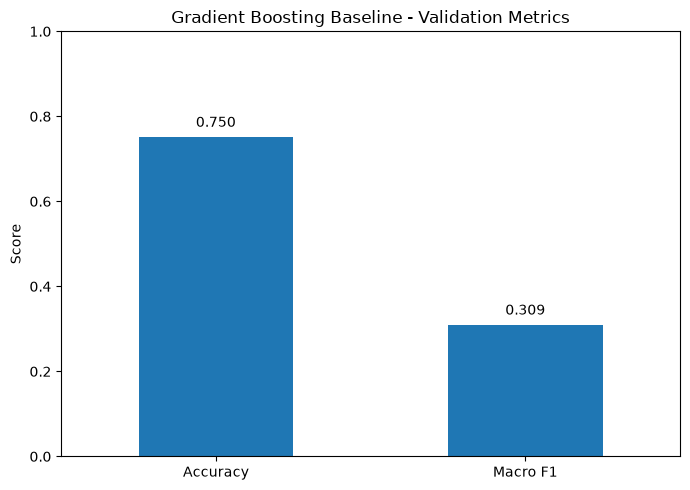

In [15]:
overall_metrics = pd.Series(
    {
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
    }
)

fig, ax = plt.subplots(figsize=(7, 5))
overall_metrics.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Gradient Boosting Baseline - Validation Metrics")
ax.tick_params(axis="x", rotation=0)

for i, value in enumerate(overall_metrics.values):
    ax.text(i, min(value + 0.025, 0.97), f"{value:.3f}", ha="center")

plt.tight_layout()

overall_metrics_picture = (
    pictures_dir / "gradient_boosting_baseline_metrics.png"
)
plt.savefig(overall_metrics_picture, dpi=300, bbox_inches="tight")
print("Saved:", overall_metrics_picture)
plt.show()


## 15. Save Class-wise Precision, Recall and F1 Diagram

This diagram makes it easier to see whether the model performs differently across PM2.5 risk classes.


Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\gradient_boosting_class_metrics.png


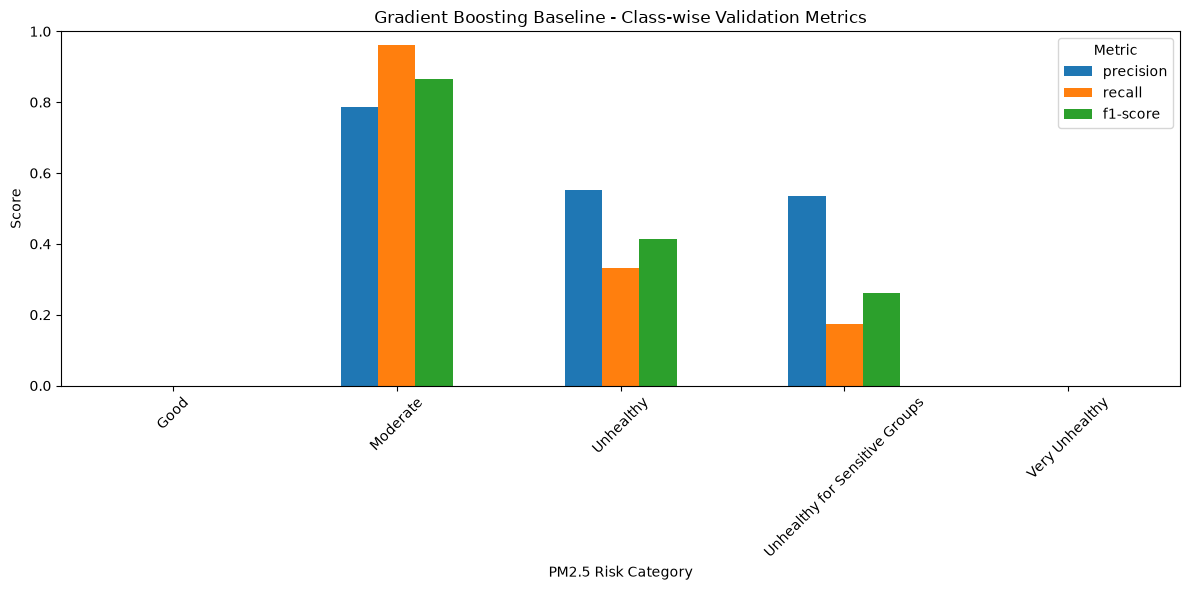

In [16]:
class_names = [
    label for label in labels
    if label in classification_report_df.index
]

class_metrics = classification_report_df.loc[
    class_names,
    ["precision", "recall", "f1-score"]
]

ax = class_metrics.plot(kind="bar", figsize=(12, 6))
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_xlabel("PM2.5 Risk Category")
ax.set_title("Gradient Boosting Baseline - Class-wise Validation Metrics")
ax.tick_params(axis="x", rotation=45)
plt.legend(title="Metric")
plt.tight_layout()

class_metrics_picture = (
    pictures_dir / "gradient_boosting_class_metrics.png"
)
plt.savefig(class_metrics_picture, dpi=300, bbox_inches="tight")
print("Saved:", class_metrics_picture)
plt.show()


## 16. Feature Importance

Gradient Boosting provides feature-importance scores. These scores help identify which transformed input features contributed most to the model's decisions.

Feature importance is used here for **interpretation of the baseline model**, not as a feature-selection optimization step.


In [17]:
try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = np.array(
        [f"feature_{i}" for i in range(X_train_processed.shape[1])]
    )

feature_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": gb_baseline.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importance_path = (
    results_dir / "gradient_boosting_feature_importance.csv"
)
feature_importance_df.to_csv(feature_importance_path, index=False)

print("Saved:", feature_importance_path)
feature_importance_df.head(20)


Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\gradient_boosting_feature_importance.csv


,feature,importance
6,numeric__arithmetic_standard_dev,0.176132
10,numeric__ninety_five_percentile,0.138402
0,numeric__year,0.112543
9,numeric__ninety_eight_percentile,0.073143
11,numeric__ninety_percentile,0.067758
7,numeric__first_max_value,0.065046
2,numeric__longitude,0.064843
1,numeric__latitude,0.034364
18,numeric__pm25_pct_change_1yr,0.030529
3,numeric__observation_count,0.025600


## 17. Save Top Feature Importance Diagram

For readability, the diagram displays the 15 most important transformed features.


Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\gradient_boosting_feature_importance.png


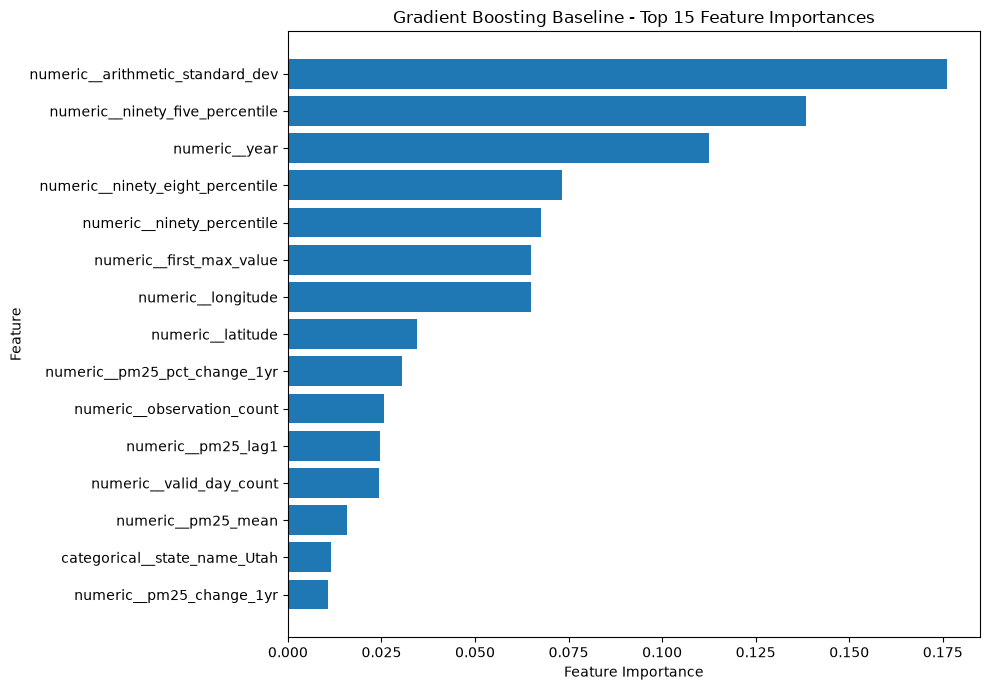

In [18]:
top_features = feature_importance_df.head(15).sort_values(
    "importance",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_features["feature"], top_features["importance"])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("Gradient Boosting Baseline - Top 15 Feature Importances")
plt.tight_layout()

feature_importance_picture = (
    pictures_dir / "gradient_boosting_feature_importance.png"
)
plt.savefig(feature_importance_picture, dpi=300, bbox_inches="tight")
print("Saved:", feature_importance_picture)
plt.show()


## 18. Output Check

The baseline experiment should now produce:

**CSV evidence**
- `gradient_boosting_baseline_results.csv`
- `gradient_boosting_classification_report.csv`
- `gradient_boosting_feature_importance.csv`

**Figures**
- `gradient_boosting_baseline_confusion_matrix.png`
- `gradient_boosting_baseline_metrics.png`
- `gradient_boosting_class_metrics.png`
- `gradient_boosting_feature_importance.png`


In [19]:
expected_outputs = [
    results_dir / "gradient_boosting_baseline_results.csv",
    results_dir / "gradient_boosting_classification_report.csv",
    results_dir / "gradient_boosting_feature_importance.csv",
    pictures_dir / "gradient_boosting_baseline_confusion_matrix.png",
    pictures_dir / "gradient_boosting_baseline_metrics.png",
    pictures_dir / "gradient_boosting_class_metrics.png",
    pictures_dir / "gradient_boosting_feature_importance.png",
]

print("RANDOM FOREST BASELINE OUTPUT CHECK")
print("=" * 55)

for output_path in expected_outputs:
    status = "OK" if output_path.exists() else "MISSING"
    print(f"{status:7} | {output_path}")


RANDOM FOREST BASELINE OUTPUT CHECK
OK      | g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\gradient_boosting_baseline_results.csv
OK      | g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\gradient_boosting_classification_report.csv
OK      | g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\gradient_boosting_feature_importance.csv
OK      | g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\gradient_boosting_baseline_confusion_matrix.png
OK      | g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\gradient_boosting_baseline_metrics.png
OK      | g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\gradient_boosting_class_metrics.png
OK      | g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\gradient_boosting_feature_importance.png


## Final Baseline Model Summary

The Gradient Boosting baseline was trained on the chronological training set and evaluated on the validation set.

The preprocessing transformer was fitted only on training features and then applied to validation data to avoid information leakage.

The notebook records overall performance, class-wise performance, prediction errors through a confusion matrix, and Gradient Boosting feature importance.

No hyperparameter tuning or model optimization is performed here. These results form the **baseline evidence** that can later be compared with Random Forest, optimized models, and the other algorithms developed by the group.

The chronological test set is kept separate from baseline model selection and should be reserved for final-model evaluation.
